# DiffIndEye Fine Tuning

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source dir:", SRC_DIR)
print("Source dir exists:", SRC_DIR.exists())

Project root: /Users/jonathanma/Desktop/DS Projects/diff-in-eye
Source dir: /Users/jonathanma/Desktop/DS Projects/diff-in-eye/src
Source dir exists: True


In [3]:
from pathlib import Path
from datetime import datetime

import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from diffindeye.config import (
    TRAIN_DIR,
    TEST_DIR,
    CHECKPOINT_DIR,
    METRICS_DIR,
    T,
    BETA_START,
    BETA_END,
)

from diffindeye.data import (
    get_image_paths,
    make_dataloader,
)

from diffindeye.diff_models import (
    ConditionalTimeDDPM,
)

from diffindeye.diff_schedules import (
    make_linear_schedule,
)

from diffindeye.diff_train import (
    train_conditional_ddpm,
    save_training_checkpoint,
    load_training_checkpoint,
)

from diffindeye.diff_sampling import (
    sample_conditional_inpaint,
)

from diffindeye.evaluation import (
    evaluate_all_methods,
    method_summary,
)

# Reproducibility
SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("Diff-in-Eye — Diffusion Tuning Notebook")
print("=" * 60)

print(f"Device:           {device}")
print(f"PyTorch version:  {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU:              {torch.cuda.get_device_name(0)}")

print()

# Paths
train_paths = get_image_paths(TRAIN_DIR)
test_paths = get_image_paths(TEST_DIR)

print("Dataset")
print("-" * 60)
print(f"Train images: {len(train_paths)}")
print(f"Test images:  {len(test_paths)}")

print()

print("Checkpoint directory")
print("-" * 60)
print(CHECKPOINT_DIR)

print()

print("Metrics directory")
print("-" * 60)
print(METRICS_DIR)

Diff-in-Eye — Diffusion Tuning Notebook
Device:           cpu
PyTorch version:  2.12.0

Dataset
------------------------------------------------------------
Train images: 18400
Test images:  2800

Checkpoint directory
------------------------------------------------------------
/Users/jonathanma/Desktop/DS Projects/diff-in-eye/results/checkpoints

Metrics directory
------------------------------------------------------------
/Users/jonathanma/Desktop/DS Projects/diff-in-eye/results/metrics


In [4]:
# Experiment Configuration
EXPERIMENT_NAME = "baseline_conditional_ddpm"

# Training Hyperparameters
N_STEPS = 1000
BATCH_SIZE = 8
LEARNING_RATE = 1e-4

# Diffusion Hyperparameters
TIME_EMB_DIM = 32

# Training Behavior
USE_MASKED_LOSS = True

CHECKPOINT_EVERY = 250
LOG_EVERY = 50

# Sampling
SAMPLE_STEPS = 100

# Evaluation
N_EVAL_SAMPLES = 25

# Derived Run Info
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ID = f"{EXPERIMENT_NAME}_{timestamp}"

print("=" * 60)
print("Experiment Configuration")
print("=" * 60)

print(f"RUN_ID:             {RUN_ID}")
print()
print(f"N_STEPS:            {N_STEPS}")
print(f"BATCH_SIZE:         {BATCH_SIZE}")
print(f"LEARNING_RATE:      {LEARNING_RATE}")
print(f"TIME_EMB_DIM:       {TIME_EMB_DIM}")
print(f"USE_MASKED_LOSS:    {USE_MASKED_LOSS}")
print(f"CHECKPOINT_EVERY:   {CHECKPOINT_EVERY}")
print(f"LOG_EVERY:          {LOG_EVERY}")
print(f"SAMPLE_STEPS:       {SAMPLE_STEPS}")
print(f"N_EVAL_SAMPLES:     {N_EVAL_SAMPLES}")

Experiment Configuration
RUN_ID:             baseline_conditional_ddpm_20260523_145301

N_STEPS:            1000
BATCH_SIZE:         8
LEARNING_RATE:      0.0001
TIME_EMB_DIM:       32
USE_MASKED_LOSS:    True
CHECKPOINT_EVERY:   250
LOG_EVERY:          50
SAMPLE_STEPS:       100
N_EVAL_SAMPLES:     25


In [5]:
# Build DataLoader + Diffusion Schedule
train_loader = make_dataloader(
    image_paths=train_paths,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

schedule = make_linear_schedule(
    t_steps=T,
    beta_start=BETA_START,
    beta_end=BETA_END,
    device=device,
)

alpha_bars = schedule["alpha_bars"]

# Quick Sanity Checks
batch = next(iter(train_loader))

print("=" * 60)
print("Training Setup Sanity Check")
print("=" * 60)

print()
print("Batch Shapes")
print("-" * 60)

for key, value in batch.items():
    if hasattr(value, "shape"):
        print(f"{key}: {value.shape}")

print()
print("Diffusion Schedule")
print("-" * 60)

print(f"alpha_bars shape: {alpha_bars.shape}")
print(f"alpha_bar[0]:     {alpha_bars[0].item():.6f}")
print(f"alpha_bar[-1]:    {alpha_bars[-1].item():.6f}")

Training Setup Sanity Check

Batch Shapes
------------------------------------------------------------
image: torch.Size([8, 1, 128, 256])
mask: torch.Size([8, 1, 128, 256])
masked_image: torch.Size([8, 1, 128, 256])

Diffusion Schedule
------------------------------------------------------------
alpha_bars shape: torch.Size([1000])
alpha_bar[0]:     0.999900
alpha_bar[-1]:    0.000040


In [6]:
# Initialize Model + Optimizer
model = ConditionalTimeDDPM(
    time_emb_dim=TIME_EMB_DIM
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

n_params = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("Model Summary")
print("=" * 60)

print(model)
print()
print(f"Number of parameters: {n_params:,}")

Model Summary
ConditionalTimeDDPM(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
  )
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (time_proj): Linear(in_features=32, out_features=64, bias=True)
)

Number of parameters: 115,169


In [7]:
# Train Model
run_dir = CHECKPOINT_DIR / RUN_ID
run_dir.mkdir(parents=True, exist_ok=True)

losses = train_conditional_ddpm(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    alpha_bars=alpha_bars,
    device=device,
    n_steps=N_STEPS,
    use_masked_loss=USE_MASKED_LOSS,
    log_every=LOG_EVERY,
    checkpoint_every=CHECKPOINT_EVERY,
    checkpoint_dir=run_dir,
    checkpoint_name=EXPERIMENT_NAME,
    extra_checkpoint_info={
        "run_id": RUN_ID,
        "n_steps": N_STEPS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "time_emb_dim": TIME_EMB_DIM,
        "use_masked_loss": USE_MASKED_LOSS,
        "sample_steps": SAMPLE_STEPS,
    },
)

final_step = N_STEPS
final_checkpoint = run_dir / f"{EXPERIMENT_NAME}_final_step_{final_step}.pt"

save_training_checkpoint(
    checkpoint_path=final_checkpoint,
    model=model,
    optimizer=optimizer,
    losses=losses,
    step=final_step,
    extra={
        "run_id": RUN_ID,
        "n_steps": N_STEPS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "time_emb_dim": TIME_EMB_DIM,
        "use_masked_loss": USE_MASKED_LOSS,
    },
)

print("Final checkpoint saved to:")
print(final_checkpoint)

  0%|          | 0/1000 [00:00<?, ?it/s]

Final checkpoint saved to:
/Users/jonathanma/Desktop/DS Projects/diff-in-eye/results/checkpoints/baseline_conditional_ddpm_20260523_145301/baseline_conditional_ddpm_final_step_1000.pt


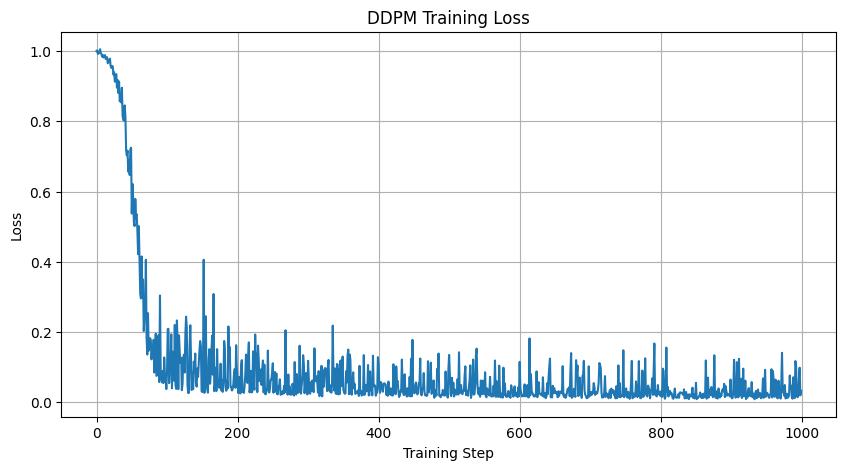

Final loss: 0.032627
Minimum loss: 0.008593
Mean last 50 losses: 0.038063


In [8]:
# Plot Training Loss
plt.figure(figsize=(10, 5))

plt.plot(losses)

plt.title("DDPM Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

print(f"Final loss: {losses[-1]:.6f}")
print(f"Minimum loss: {min(losses):.6f}")
print(f"Mean last 50 losses: {np.mean(losses[-50:]):.6f}")

In [9]:
# Evaluate Trained DDPM Against Baselines
results_df = evaluate_all_methods(
    image_paths=test_paths,
    model=model,
    alpha_bars=alpha_bars,
    device=device,
    n_samples=N_EVAL_SAMPLES,
    sample_steps=SAMPLE_STEPS,
    verbose=True,
)

summary_df = method_summary(results_df)

print("=" * 60)
print("Method Comparison")
print("=" * 60)

summary_df

Processing 1/25
Processing 2/25
Processing 3/25
Processing 4/25
Processing 5/25
Processing 6/25
Processing 7/25
Processing 8/25
Processing 9/25
Processing 10/25
Processing 11/25
Processing 12/25
Processing 13/25
Processing 14/25
Processing 15/25
Processing 16/25
Processing 17/25
Processing 18/25
Processing 19/25
Processing 20/25
Processing 21/25
Processing 22/25
Processing 23/25
Processing 24/25
Processing 25/25
Method Comparison


,method,mean_mse,mean_mae,mean_psnr
3,telea,0.011193,0.070674,28.576843
2,pde,0.032117,0.150624,22.806791
1,gaussian,0.135240,0.351910,16.138763
4,zero,0.168830,0.398078,15.146725
0,ddpm,0.339666,0.572242,12.005756


In [ ]:
# TODO: U-Net DDPM